# 📊 Project Analisis Data: CerminSaku

## Business Questions:
- Kategori pengeluaran apa yang mengalami peningkatan terbesar (≥15%) pada pengguna selama periode Januari–Maret 2023, dan bagaimana hal tersebut memengaruhi total pengeluaran bulanan pengguna?
- Seberapa sering pengguna mengalami kondisi overbudget (pengeluaran > pemasukan) dalam periode 3 bulan, dan berapa rata-rata selisih defisit yang terjadi?
- Apakah terdapat perbedaan rata-rata pengeluaran harian antara hari kerja dan akhir pekan (≥20%), dan kategori apa yang paling berkontribusi terhadap perbedaan tersebut dalam periode 1 tahun?

# Menyiapkan Semua Library yang Dibutuhkan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Wrangling

## Gathering Data
Dataset diperoleh dari Kaggle: https://www.kaggle.com/datasets/ramyapintchy/personal-finance-data dengan sedikit modifikasi yaitu penambahan data dummy sejumlah 10.000 records untuk meningkatkan jumlah data serta mensimulasikan perilaku transaksi pengguna secara lebih realistis, sehingga analisis yang dilakukan menjadi lebih representatif.

In [2]:
df_raw = pd.read_csv('/content/Personal_Finance_Dataset_11500.csv')
df_raw.head()

,Date,Transaction Description,Category,Amount,Type
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense


In [3]:
df_raw.tail()

,Date,Transaction Description,Category,Amount,Type
11495,2021-07-28,McDonalds,Food & Drink,48.38,Expense
11496,2022-01-31,Netflix,Entertainment,41.90,Expense
11497,2022-11-13,Cinema,Entertainment,133.69,Expense
11498,2021-08-02,Electricity Bill,Utilities,12.59,Expense
11499,2021-06-19,Internet,Utilities,107.06,Expense


## Assessing Data

In [4]:
#Mengecek Tipe Data
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     11500 non-null  object 
 1   Transaction Description  11500 non-null  object 
 2   Category                 11500 non-null  object 
 3   Amount                   11500 non-null  float64
 4   Type                     11500 non-null  object 
dtypes: float64(1), object(4)
memory usage: 449.3+ KB


Dari hasil di atas, terlihat bahwa kolom `Date` masih bertipe data `object`.
Hal ini menunjukkan bahwa data tanggal belum dalam format `datetime` sehingga perlu dikonversi pada tahap data cleaning agar dapat digunakan untuk analisis berbasis waktu.

In [5]:
#Mengecek Nilai Unik pada Kolom Type
df_raw['Type'].unique()

array(['Expense', 'Income'], dtype=object)

Berdasarkan hasil pengecekan di atas, nilai pada kolom `Type` sudah konsisten yaitu hanya terdiri dari `Expense` dan `Income`. Oleh karena itu, tidak diperlukan proses normalisasi atau pembersihan lebih lanjut pada kolom ini.

In [6]:
#Mengecek Nilai Unik pada Kolom Category
df_raw['Category'].unique()

array(['Food & Drink', 'Utilities', 'Rent', 'Investment', 'Shopping',
       'Other', 'Entertainment', 'Health & Fitness', 'Salary', 'Travel',
       'Income', 'Transport'], dtype=object)

Berdasarkan hasil pengecekan, terdapat ketidakkonsistenan pada kolom `Category`, dimana nilai Income tidak sesuai karena seharusnya berada pada kolom Type. Oleh karena itu, perlu dilakukan penyesuaian agar kategori tidak redundan dan lebih konsisten.

In [7]:
#Mengecek Missing Value
df_raw.isna().sum()

,0
Date,0
Transaction Description,0
Category,0
Amount,0
Type,0


Berdasarkan hasil pengecekan di atas, tidak ditemukan missing values pada seluruh kolom dalam dataset.

In [8]:
#Mengecek Duplikat
print("Jumlah duplikasi: ", df_raw.duplicated().sum())

Jumlah duplikasi:  231


Berdasarkan hasil pengecekan, terdapat 231 data duplikat dalam dataset. Perlu dilakukan penghapusan data duplikat pada tahap data cleaning agar data yang digunakan lebih akurat dan tidak bias.

In [9]:
#Mengecek Parameter Statistik
df_raw.groupby('Type')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Type,,,,,,,,
Expense,10423.0,165.961667,364.092218,5.01,31.885,56.16,79.64,1999.82
Income,1077.0,2472.675023,1981.034924,201.00,632.000,1560.00,5000.00,5000.00


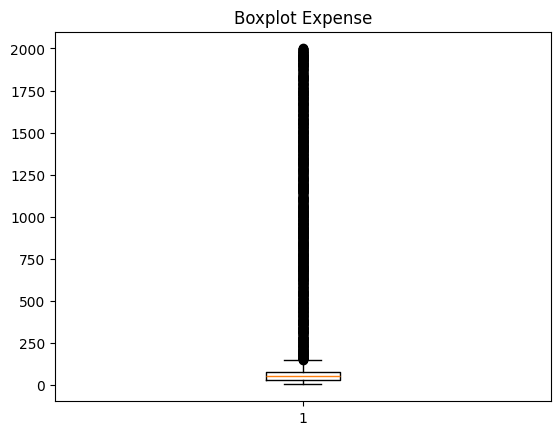

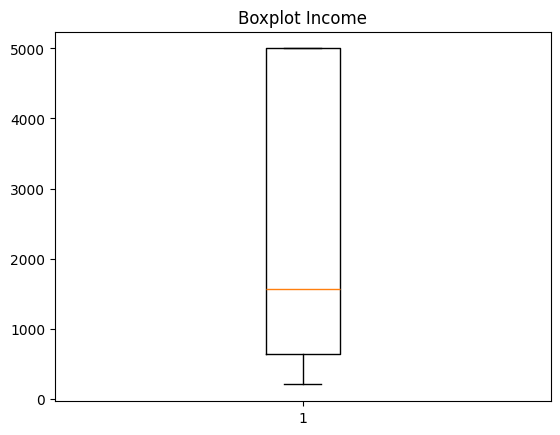

In [10]:
# Expense
plt.boxplot(df_raw[df_raw['Type']=='Expense']['Amount'])
plt.title("Boxplot Expense")
plt.show()

# Income
plt.boxplot(df_raw[df_raw['Type']=='Income']['Amount'])
plt.title("Boxplot Income")
plt.show()

Meskipun terlihat terdapat outlier pada `Expense`, hal ini masih wajar karena perbedaan jenis kategori pengeluaran. Oleh karena itu, analisis dilanjutkan dengan melihat distribusi statistik pada tiap kategori.

In [11]:
df_raw[df_raw['Type']=='Expense'].groupby('Category')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
Entertainment,1972.0,126.828185,297.085627,5.22,31.8000,54.840,77.4975,1980.56
Food & Drink,1976.0,131.174661,316.174364,5.05,30.8675,53.580,76.6850,1999.82
Health & Fitness,152.0,955.224079,588.302857,46.28,440.0600,892.415,1512.4500,1996.26
Rent,165.0,982.275091,548.040691,25.38,533.5500,918.360,1452.4400,1976.43
Salary,146.0,1020.914726,593.111690,28.48,499.7875,1082.960,1523.5125,1993.30
Shopping,1982.0,124.067563,289.535744,5.04,30.7075,54.305,75.1600,1962.27
Transport,1799.0,54.552846,33.219461,5.02,29.6450,49.930,71.6600,149.94
Travel,160.0,1059.361188,546.564958,53.66,634.2175,1132.880,1498.0075,1994.88
Utilities,2071.0,121.027948,284.579541,5.01,29.8550,54.470,76.6650,1985.77


Berdasarkan analisis per kategori, outlier terutama ditemukan pada kategori dengan pengeluaran kecil seperti `Food & Drink`, `Entertainment`, `Shopping`, dan `Utilities`, sehingga memerlukan penanganan lebih lanjut. Sementara itu, kategori lain masih menunjukkan distribusi yang wajar.

## Cleaning Data

In [12]:
# Membuat salinan dari raw data
df_clean = df_raw.copy()

In [13]:
# Mengubah tipe data kolom Date menjadi datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# Cek kembali tipe data untuk memastikan sudah berubah
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     11500 non-null  datetime64[ns]
 1   Transaction Description  11500 non-null  object        
 2   Category                 11500 non-null  object        
 3   Amount                   11500 non-null  float64       
 4   Type                     11500 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 449.3+ KB


Melakukan konversi menggunakan fungsi `pd.to_datetime`. Langkah ini penting agar kolom tersebut dapat digunakan untuk analisis berbasis waktu secara akurat, dan hasil pengecekan melalui `df_raw.info()` mengonfirmasi bahwa tipe data telah berhasil diubah menjadi datetime64[ns].

In [14]:
# Melihat kategori unik sebelum diperbaiki
print("Kategori sebelum:", df_clean['Category'].unique())

# 1. Menampilkan data dengan Category = 'Income'
print("Data dengan Category = 'Income':")
display(df_clean[df_clean['Category'] == 'Income'])

# 2. Mengecek distribusi Type pada data tersebut
print("\nDistribusi Type:")
print(df_clean[df_clean['Category'] == 'Income']['Type'].value_counts())

# 3. Mencari modus kategori untuk Type = Income (selain 'Income')
mode_income_category = df_clean[
    (df_clean['Type'] == 'Income') &
    (df_clean['Category'] != 'Income')
]['Category'].mode()[0]

# 4. Mencari modus kategori untuk Type = Expense
mode_expense_category = df_clean[
    df_clean['Type'] == 'Expense'
]['Category'].mode()[0]

print("\nModus Income:", mode_income_category)
print("Modus Expense:", mode_expense_category)

# 5. Cleaning:
# a. Jika Type = Income dan Category = 'Income' → ganti dengan modus Income
df_clean.loc[
    (df_clean['Category'] == 'Income') & (df_clean['Type'] == 'Income'),
    'Category'
] = mode_income_category

# b. Jika Type = Expense dan Category = 'Income' → ganti dengan modus Expense
df_clean.loc[
    (df_clean['Category'] == 'Income') & (df_clean['Type'] == 'Expense'),
    'Category'
] = mode_expense_category

# 6. Cek hasil akhir
print("\nKategori setelah cleaning:")
print(df_clean['Category'].unique())

Kategori sebelum: ['Food & Drink' 'Utilities' 'Rent' 'Investment' 'Shopping' 'Other'
 'Entertainment' 'Health & Fitness' 'Salary' 'Travel' 'Income' 'Transport']
Data dengan Category = 'Income':


,Date,Transaction Description,Category,Amount,Type
1500,2023-01-01,Salary,Income,4500.0,Income
1531,2023-02-01,Salary,Income,4500.0,Income
1551,2023-02-21,Freelance,Income,660.0,Income
1557,2023-02-27,Freelance,Income,512.0,Income
1559,2023-03-01,Salary,Income,4500.0,Income
...,...,...,...,...,...
11283,2024-11-11,Freelance,Income,498.0,Income
11291,2024-11-18,Freelance,Income,571.0,Income
11301,2020-07-18,Freelance,Income,399.0,Income
11371,2020-10-21,Freelance,Income,249.0,Income



Distribusi Type:
Type
Income    521
Name: count, dtype: int64

Modus Income: Salary
Modus Expense: Utilities

Kategori setelah cleaning:
['Food & Drink' 'Utilities' 'Rent' 'Investment' 'Shopping' 'Other'
 'Entertainment' 'Health & Fitness' 'Salary' 'Travel' 'Transport']


Dilakukan perbaikan nilai `Category = Income` dengan mengganti menggunakan modus kategori berdasarkan tipe transaksi (Income dan Expense) menggunakan fungsi `mode()` dan `loc()`, sehingga kategori menjadi lebih konsisten dan sesuai konteks.

In [15]:
# Menghapus data duplikat
df_clean.drop_duplicates(inplace=True)

# Cek kembali jumlah duplikat untuk memastikan sudah 0
print("Jumlah duplikat setelah dibersihkan:", df_clean.duplicated().sum())

# Jumlah data setelah penghapusan duplikat
print("Jumlah data setelah penghapusan duplikat:", df_clean.shape[0])

Jumlah duplikat setelah dibersihkan: 0
Jumlah data setelah penghapusan duplikat: 11239


Berdasarkan hasil pengecekan sebelumnya, terdapat 231 data duplikat dalam dataset. Pada tahap ini, dilakukan penghapusan data duplikat secara permanen menggunakan `drop_duplicates` agar data yang digunakan lebih akurat dan tidak bias dalam proses selanjutnya. Hasil pengecekan ulang menunjukkan bahwa jumlah duplikasi kini sudah mencapai 0.

In [16]:
# Menentukan kategori yang akan dibersihkan
target_categories = ['Food & Drink', 'Entertainment', 'Shopping', 'Utilities']

# Pisahkan data target dan non-target dari df_clean
df_target = df_clean[df_clean['Category'].isin(target_categories)]
df_others = df_clean[~df_clean['Category'].isin(target_categories)]

# Hitung IQR hanya untuk kategori target
Q1 = df_target['Amount'].quantile(0.25)
Q3 = df_target['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier hanya pada kategori target
df_target_clean = df_target[
    (df_target['Amount'] >= lower_bound) &
    (df_target['Amount'] <= upper_bound)
]

# Gabungkan kembali dengan kategori lain (tidak diubah)
df_clean = pd.concat([df_target_clean, df_others])

# Rapihin index
df_clean = df_clean.reset_index(drop=True)

# Cek hasil
print("Jumlah data setelah cleaning:", len(df_clean))

Jumlah data setelah cleaning: 10618


Dilakukan penanganan outlier pada kolom Amount menggunakan metode IQR khusus pada kategori Food & Drink, Entertainment, Shopping, dan Utilities, karena kategori tersebut memiliki nilai ekstrem yang tidak wajar dibandingkan distribusi normalnya.

In [20]:
# Export dataset yang sudah di cleaning
df_clean.to_csv('Personal_Finance_Dataset_Cleaned.csv', index=False)

# Exploratory Data Analysis (EDA)

# Feature Engineering

# Data Visualization & Explanatory Analysis